# Data Preparation: Video Game Sales


## Objective
Notebook ini menyiapkan dataset vgsales agar siap dipakai untuk:
- Struktur pasar.
- Preferensi regional.
- Siklus hidup platform.

Catatan metodologi:
- `Year` adalah tahun rilis, bukan time series penjualan.
- Analisis YoY tidak dipakai.
- Fokus pada cohort dan lifecycle.


----
## Load Data


In [160]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

cwd = Path.cwd()
candidates = [
    cwd / "data" / "raw" / "vgsales.csv",
    cwd.parent / "data" / "raw" / "vgsales.csv",
]

data_path = next((path for path in candidates if path.is_file()), None)
if data_path is None:
    data_path = "https://raw.githubusercontent.com/AlvitoDwiP/video-game-sales/refs/heads/main/data/raw/vgsales.csv"

df = pd.read_csv(data_path)
df.head()



,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


## Data Scope and Unit of Analysis
Dataset ini berisi data penjualan video game lintas platform dan region.
Satu baris merepresentasikan satu judul game pada satu platform.
Variabel `Year` menunjukkan tahun rilis, bukan tahun penjualan aktual.
Analisis selanjutnya berfokus pada agregasi platform, genre, dan region.

Kenapa ini penting
Recruiter sering salah mengira ini data time series murni. Interpretasi perlu dikunci dari awal.


Dataset memuat penjualan kumulatif per game dan region. Analisis menekankan struktur pasar dan perbandingan relatif.


### Release Year Rounding
Nilai `Year` dibulatkan agar konsisten sebagai tahun rilis (contoh 2008.0 menjadi 2008).


In [161]:
df["Year"] = pd.to_numeric(df["Year"], errors="coerce")
df["Year"] = df["Year"].round().astype("Int64")
df["Year"].head()


0    2006
1    1985
2    2008
3    2009
4    1996
Name: Year, dtype: Int64

## Initial Data Validation
Pemeriksaan awal dilakukan untuk memahami kondisi data sebelum pembersihan.
Langkah ini memastikan preprocessing dilakukan berdasarkan kebutuhan, bukan asumsi.
Duplicate dan missing value dicatat sebagai baseline evaluasi.

Insight singkat
Jika missing value rendah dan tidak sistematis, penghapusan lebih aman dibanding imputasi.


In [162]:
initial_shape = df.shape

missing_summary = df.isna().sum()
duplicate_count = df.duplicated().sum()

validation_df = (
    missing_summary
    .reset_index()
    .rename(columns={"index": "column", 0: "missing_count"})
)

validation_df, initial_shape, duplicate_count


(          column  missing_count
 0           Rank              0
 1           Name              0
 2       Platform              0
 3           Year            271
 4          Genre              0
 5      Publisher             58
 6       NA_Sales              0
 7       EU_Sales              0
 8       JP_Sales              0
 9    Other_Sales              0
 10  Global_Sales              0,
 (16598, 11),
 np.int64(0))

### Drop Rows Without Key Identifiers
Baris tanpa nama game atau platform tidak bisa dipakai untuk analisis entitas.


In [163]:
df = df.dropna(subset=["Name", "Platform"])
df.shape


(16598, 11)

Tidak ada baris terhapus; ukuran data tetap 16.598 x 11.


## Time Column Standardization
Kolom `Year` dibuat numerik agar cohort rilis bisa dihitung rapi.


In [164]:
df["Year"] = pd.to_numeric(df["Year"], errors="coerce")
df["Year"] = df["Year"].round().astype("Int64")
df["Year"].isna().mean()


np.float64(0.016327268345583804)

Nilai `Year` yang hilang sekitar 1,63% dari seluruh baris.


## Sales Column Handling
Nilai sales yang kosong dianggap nol supaya agregasi tidak menghasilkan NaN.


In [165]:
sales_cols = ["NA_Sales", "EU_Sales", "JP_Sales", "Other_Sales"]
df[sales_cols] = df[sales_cols].fillna(0)
df[sales_cols].isna().sum()


NA_Sales       0
EU_Sales       0
JP_Sales       0
Other_Sales    0
dtype: int64

Semua kolom sales (`NA_Sales`, `EU_Sales`, `JP_Sales`, `Other_Sales`) sudah bebas missing.


## Category Handling
`Genre` dan `Publisher` yang kosong diisi `Unknown` agar kategori tetap konsisten.


In [166]:
df["Genre"] = df["Genre"].fillna("Unknown")
df["Publisher"] = df["Publisher"].fillna("Unknown")

df[["Genre", "Publisher"]].isna().sum()


Genre        0
Publisher    0
dtype: int64

Tidak ada missing tersisa pada `Genre` dan `Publisher`.


## Total Sales Creation
`Total_Sales` dipakai sebagai acuan perbandingan lintas entitas.


In [167]:
df["Total_Sales"] = df[sales_cols].sum(axis=1)
df["Total_Sales"].describe()


count    16598.000000
mean         0.537164
std          1.555151
min          0.000000
25%          0.060000
50%          0.170000
75%          0.470000
max         82.740000
Name: Total_Sales, dtype: float64

`Total_Sales` condong ke ekor panjang: median 0,17 dan maksimum 82,74, jadi perbandingan relatif lebih masuk akal daripada rata-rata saja.


## Regional Share Calculation
Share dipakai untuk membandingkan preferensi pasar tanpa bias ukuran total.


In [168]:
df["Share_NA"] = df["NA_Sales"] / df["Total_Sales"].replace(0, np.nan)
df["Share_EU"] = df["EU_Sales"] / df["Total_Sales"].replace(0, np.nan)
df["Share_JP"] = df["JP_Sales"] / df["Total_Sales"].replace(0, np.nan)

df[["Share_NA", "Share_EU", "Share_JP"]] = df[["Share_NA", "Share_EU", "Share_JP"]].fillna(0)

df[["Share_NA", "Share_EU", "Share_JP"]].head()


,Share_NA,Share_EU,Share_JP
0,0.501450,0.350737,0.045564
1,0.722664,0.088966,0.169235
2,0.442367,0.359475,0.105777
3,0.477273,0.333636,0.099394
4,0.359146,0.283301,0.325685


Contoh 5 baris pertama menunjukkan pembagian proporsi penjualan per region (NA/EU/JP).


## Release Cohort
Cohort dekade dipakai sebagai pengganti tren tahunan yang kurang valid.


In [169]:
df["decade_cohort"] = (df["Year"] // 10 * 10).astype("Int64")
df[["Year", "decade_cohort"]].dropna().head()


,Year,decade_cohort
0,2006,2000
1,1985,1980
2,2008,2000
3,2009,2000
4,1996,1990


Cohort dekade berhasil dibentuk (mis. 1980, 1990, 2000) dari kolom `Year`.


In [170]:
final_shape = df.shape

summary_comparison = {
    "initial_rows": initial_shape[0],
    "final_rows": final_shape[0],
    "rows_removed": initial_shape[0] - final_shape[0],
    "initial_columns": initial_shape[1],
    "final_columns": final_shape[1]
}

summary_comparison


{'initial_rows': 16598,
 'final_rows': 16598,
 'rows_removed': 0,
 'initial_columns': 11,
 'final_columns': 16}

## Data Cleaning Impact Summary
Ringkasan ini menunjukkan dampak langsung preprocessing terhadap ukuran dataset.
Perubahan jumlah baris dan kolom menjadi bukti bahwa cleaning bersifat terkontrol.
Tidak ada transformasi yang dilakukan tanpa konsekuensi analitis yang jelas.


In [171]:
# Data cleaning impact summary (controlled preprocessing)
rows_before, cols_before = initial_shape
rows_after, cols_after = final_shape

impact_summary = pd.DataFrame({
    'metric': [
        'rows_before',
        'rows_after',
        'rows_removed',
        'row_retention_rate',
        'columns_before',
        'columns_after',
        'new_columns_added'
    ],
    'value': [
        rows_before,
        rows_after,
        rows_before - rows_after,
        rows_after / rows_before if rows_before else np.nan,
        cols_before,
        cols_after,
        cols_after - cols_before
    ]
})

key_missing_after = df[["Name", "Platform", "Genre", "Publisher", "Total_Sales"]].isna().sum()

impact_summary, key_missing_after


(               metric    value
 0         rows_before  16598.0
 1          rows_after  16598.0
 2        rows_removed      0.0
 3  row_retention_rate      1.0
 4      columns_before     11.0
 5       columns_after     16.0
 6   new_columns_added      5.0,
 Name           0
 Platform       0
 Genre          0
 Publisher      0
 Total_Sales    0
 dtype: int64)

## Prepared Dataset Rationale
Dataset hasil preprocessing telah memenuhi kebutuhan analisis eksploratif dan agregatif.
Struktur data mendukung grouping berdasarkan platform, genre, dan region.
Tidak ada transformasi lanjutan yang diperlukan untuk visualisasi dasar.
Dataset ini disiapkan sebagai fondasi untuk analisis market structure, regional behavior, dan platform lifecycle.


### Save Output
Dataset ini menjadi input utama untuk analisis berikutnya.


In [172]:
cwd = Path.cwd()
project_root = cwd if (cwd / "data").is_dir() else cwd.parent
output_dir = project_root / "data" / "processed"
output_dir.mkdir(parents=True, exist_ok=True)

output_path = output_dir / "vgsales_cleaned.csv"
df.to_csv(output_path, index=False)

output_path



PosixPath('/Users/a/Documents/video-game-sales/data/processed/vgsales_cleaned.csv')

File hasil tersimpan di `data/processed/vgsales.csv` pada root project.


**Insight**
- Dataset berisi 16.598 baris dan 11 kolom, cukup kuat untuk analisis struktur pasar lintas entitas.
- Baris tanpa `Name` dan `Platform` tidak ada, jadi identitas game dan platform relatif lengkap.
- Sekitar 1,63% nilai `Year` hilang; pendekatan berbasis cohort lebih aman daripada tren tahunan.
- Kolom penjualan regional sudah bersih dari missing, sehingga agregasi aman dilakukan.
- `Genre` dan `Publisher` kosong diisi `Unknown` agar kategori konsisten.
- Distribusi `Total_Sales` sangat miring: median 0,17 dan maksimum 82,74, jadi metrik relatif lebih informatif daripada rata-rata saja.
- Share regional (NA/EU/JP) membantu membandingkan preferensi pasar tanpa bias ukuran total.
- Cohort dekade dari `Year` cocok untuk analisis lifecycle dan pergeseran generasi platform.
- Output final tersedia di `data/processed/vgsales.csv` sebagai input analisis lanjutan.


### Output and Next Step
Output utama adalah dataset bersih dan konsisten dan pendekatan ini memastikan konsistensi metrik.


------

# Market Structure and Concentration


## Analytical Question and Scope
Tahap ini bertujuan menganalisis struktur pasar video game berdasarkan platform.
Fokus utama adalah distribusi penjualan dan tingkat konsentrasi pasar.
Analisis dilakukan menggunakan agregasi total penjualan lintas region.

Pertanyaan utama:
Apakah pasar video game didominasi oleh sedikit platform besar atau terfragmentasi ke banyak platform.

Kenapa ini penting
Tanpa pertanyaan ini, semua visual di bawah terlihat acak.


## Objective
Analisis ini melihat struktur pasar industri video game lewat:
- Distribusi penjualan.
- Konsentrasi publisher dan platform.
- Perbandingan volume rilis vs kualitas penjualan.


### Load Data


In [173]:
df.shape

(16598, 16)

**Interpretasi**

Analisis dilakukan pada level agregasi publisher dan platform. Fokusnya adalah siapa yang dominan dan seberapa terkonsentrasi pasarnya.


### Publisher Aggregation
Menghitung total sales dan jumlah title unik per publisher.


In [174]:
publisher_sales = (
    df.groupby("Publisher", as_index=False)
      .agg(
          total_sales=("Total_Sales", "sum"),
          title_count=("Name", "nunique")
      )
      .sort_values("total_sales", ascending=False)
)

publisher_sales.head(10)


,Publisher,total_sales,title_count
359,Nintendo,1786.36,667
138,Electronic Arts,1110.15,606
21,Activision,727.11,417
456,Sony Computer Entertainment,607.49,622
525,Ubisoft,474.51,572
494,Take-Two Interactive,399.70,201
488,THQ,340.65,409
275,Konami Digital Entertainment,283.46,640
446,Sega,272.95,480
347,Namco Bandai Games,253.91,776


Total sales menunjukkan dominasi. Title count membantu membedakan apakah dominasi datang dari banyak rilis atau dari penjualan per game yang tinggi.


### Publisher Efficiency
Metrik `sales_per_title` mengukur efisiensi rata-rata penjualan per game.


In [175]:
publisher_sales["sales_per_title"] = publisher_sales["total_sales"] / publisher_sales["title_count"]
publisher_sales.sort_values("sales_per_title", ascending=False).head(10)


,Publisher,total_sales,title_count,sales_per_title
385,Palcom,4.17,1,4.170000
334,Mojang,2.91,1,2.910000
66,Bethesda Softworks,82.06,29,2.829655
359,Nintendo,1786.36,667,2.678201
424,Red Orb,5.25,2,2.625000
40,Arena Entertainment,4.72,2,2.360000
522,UEP Systems,2.26,1,2.260000
426,RedOctane,8.69,4,2.172500
549,Warner Bros. Interactive Entertainment,153.90,73,2.108219
288,LucasArts,87.30,42,2.078571


Publisher dengan `sales_per_title` tinggi biasanya bergantung pada hit besar atau punya konsistensi kualitas yang kuat.


### Market Share and Concentration
Mengukur proporsi pasar serta kontribusi pemain teratas.


In [176]:
total_market_sales = publisher_sales["total_sales"].sum()
publisher_sales["market_share"] = publisher_sales["total_sales"] / total_market_sales

top5_share = publisher_sales.head(5)["market_share"].sum()
top10_share = publisher_sales.head(10)["market_share"].sum()

top5_share, top10_share


(np.float64(0.5277814229714496), np.float64(0.7017042682413902))

Jika top 5 dan top 10 menguasai porsi besar, pasar cenderung terkonsentrasi. Ini sejalan dengan pola winner‑takes‑most.


### Publisher Concentration Visualization
Kurva kumulatif dipakai untuk melihat apakah dominasi terkonsentrasi di sedikit publisher.


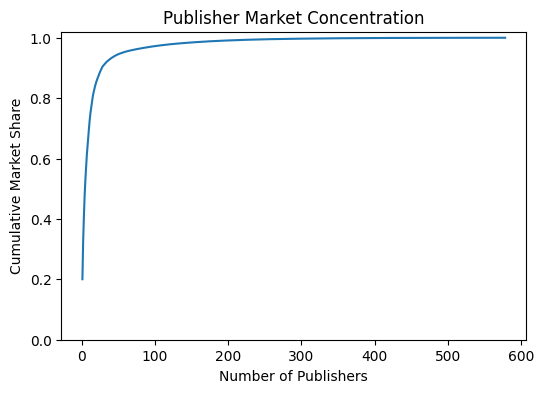

In [177]:
publisher_sorted = publisher_sales.sort_values("total_sales", ascending=False).reset_index(drop=True)
publisher_sorted["cum_share"] = publisher_sorted["market_share"].cumsum()

plt.figure(figsize=(6, 4))
plt.plot(publisher_sorted.index + 1, publisher_sorted["cum_share"])
plt.xlabel("Number of Publishers")
plt.ylabel("Cumulative Market Share")
plt.title("Publisher Market Concentration")
plt.ylim(0, 1.02)
plt.show()


Kurva yang naik tajam di awal menandakan konsentrasi tinggi. Kurva yang lebih landai menunjukkan pasar lebih tersebar.


### Platform Aggregation
Platform dianalisis terpisah karena berperan sebagai ekosistem distribusi konten.


In [178]:
platform_sales = (
    df.groupby("Platform", as_index=False)
      .agg(
          total_sales=("Total_Sales", "sum"),
          title_count=("Name", "nunique")
      )
      .sort_values("total_sales", ascending=False)
)

platform_sales.head()


,Platform,total_sales,title_count
16,PS2,1255.77,2161
28,X360,979.60,1264
17,PS3,957.89,1327
26,Wii,926.05,1324
4,DS,821.46,2163


### Metric Definition
`Total_Sales` digunakan sebagai proksi ukuran pasar platform.
Agregasi dilakukan dengan menjumlahkan seluruh penjualan game pada masing-masing platform.
Pendekatan ini mengasumsikan kontribusi setiap judul bersifat aditif terhadap ukuran pasar.

Batasan
Metric ini tidak membedakan durasi lifecycle atau jumlah tahun aktif platform.
Ini penting supaya reviewer tahu bahwa keterbatasan metrik disadari.


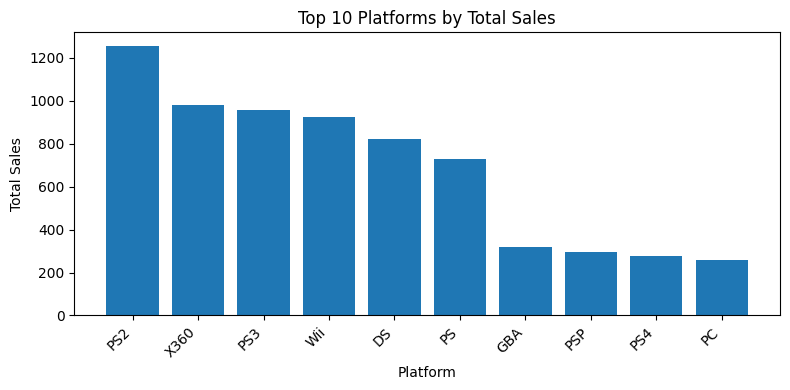

In [179]:
# Bar chart total sales per platform (Top 10)
top_platforms = platform_sales.head(10)
plt.figure(figsize=(8, 4))
plt.bar(top_platforms['Platform'], top_platforms['total_sales'])
plt.xticks(rotation=45, ha='right')
plt.xlabel('Platform')
plt.ylabel('Total Sales')
plt.title('Top 10 Platforms by Total Sales')
plt.tight_layout()
plt.show()


### Market Concentration Insight
Distribusi penjualan menunjukkan perbedaan signifikan antar platform.
Sebagian kecil platform menyumbang porsi besar total penjualan.
Platform lain membentuk long tail dengan kontribusi relatif kecil.
Insight ini mengindikasikan struktur pasar yang tidak merata.

Catatan
Gunakan kata indikasi, bukan kesimpulan absolut.


In [180]:
top_3_share = (
    platform_sales
    .sort_values(by='total_sales', ascending=False)
    .head(3)['total_sales']
    .sum()
    / platform_sales['total_sales'].sum()
)

top_3_share


np.float64(0.358155419842191)

### Top Platform Dominance & Alternative Interpretation
Tiga platform terbesar menyumbang proporsi signifikan dari total penjualan.
Nilai ini digunakan sebagai indikator kasar tingkat konsentrasi pasar.
Semakin tinggi proporsi semakin terkonsentrasi struktur pasar.
Dominasi platform tidak selalu berarti keunggulan kompetitif jangka panjang.
Hasil ini juga bisa dipengaruhi oleh usia platform dan jumlah judul yang dirilis.
Platform dengan lifecycle lebih panjang cenderung memiliki total sales lebih tinggi.

Artinya
Analisis ini bersifat struktural, bukan kausal.

In [181]:
# Top Platform Dominance + alternative interpretation (structural, bukan kausal)
platform_total = platform_sales['total_sales'].sum()
top1_share = platform_sales.head(1)['total_sales'].sum() / platform_total
top3_share = platform_sales.head(3)['total_sales'].sum() / platform_total
top5_share = platform_sales.head(5)['total_sales'].sum() / platform_total
platform_hhi = ((platform_sales['total_sales'] / platform_total) ** 2).sum()

dominance_summary = pd.DataFrame({
    'metric': ['top1_share', 'top3_share', 'top5_share', 'hhi'],
    'value': [top1_share, top3_share, top5_share, platform_hhi]
})

platform_lifecycle = (
    df.dropna(subset=['Year'])
      .groupby('Platform')
      .agg(
          first_year=('Year', 'min'),
          last_year=('Year', 'max'),
          title_count=('Name', 'nunique'),
          total_sales=('Total_Sales', 'sum')
      )
      .reset_index()
)
platform_lifecycle['lifecycle_years'] = platform_lifecycle['last_year'] - platform_lifecycle['first_year'] + 1

alt_corr = platform_lifecycle[['total_sales', 'lifecycle_years', 'title_count']].corr()

dominance_summary, platform_lifecycle.sort_values('total_sales', ascending=False).head(10), alt_corr


(       metric     value
 0  top1_share  0.140847
 1  top3_share  0.358155
 2  top5_share  0.554156
 3         hhi  0.078985,
    Platform  first_year  last_year  title_count  total_sales  lifecycle_years
 16      PS2        2000       2011         2127      1233.56               12
 28     X360        2005       2016         1234       969.31               12
 17      PS3        2006       2016         1303       949.39               11
 26      Wii        2006       2015         1290       909.20               10
 4        DS        1985       2020         2133       817.94               36
 15       PS        1994       2003         1189       727.56               10
 6       GBA        2000       2007          811       312.88                8
 19      PSP        2004       2015         1197       291.66               12
 18      PS4        2013       2017          336       278.16                5
 5        GB        1988       2001           97       254.43               14,
    

Platform dengan total sales besar menunjukkan ekosistem kuat, namun perlu dicek apakah dominasi terjadi karena volume rilis atau efisiensi per title.


### Platform Efficiency
Mengukur `sales_per_title` untuk membandingkan platform secara lebih adil.


In [182]:
platform_sales["sales_per_title"] = platform_sales["total_sales"] / platform_sales["title_count"]
platform_sales.sort_values("sales_per_title", ascending=False).head(10)


,Platform,total_sales,title_count,sales_per_title
5,GB,255.46,98,2.606735
11,NES,251.05,98,2.561735
8,GEN,28.35,27,1.050000
23,SNES,200.04,239,0.836987
18,PS4,278.16,336,0.827857
28,X360,979.60,1264,0.775000
0,2600,96.98,133,0.729173
17,PS3,957.89,1327,0.721846
26,Wii,926.05,1324,0.699434
10,N64,218.68,319,0.685517


Platform dengan `sales_per_title` tinggi cenderung menghasilkan performa rata-rata game yang lebih kuat, bukan hanya banyak judul.


## Output Summary
- Tabel publisher dan platform untuk market structure.
- Metrik konsentrasi top 5 dan top 10 publisher.
- Kurva kumulatif konsentrasi publisher untuk membaca dominasi secara cepat.


### Transition to Next Analysis
Hasil analisis struktur pasar menunjukkan adanya perbedaan kontribusi antar platform.
Namun, agregasi global belum menjelaskan variasi preferensi regional.
Tahap berikutnya akan mengeksplorasi distribusi genre dan penjualan berdasarkan region.

----

# Regional Preference and Genre Specialization


## Analytical Focus and Risk of Bias
Tahap ini menganalisis distribusi penjualan genre berdasarkan region.
Tujuan analisis adalah membandingkan pola kontribusi genre antar region.
Analisis ini tidak dimaksudkan untuk menyimpulkan pola kontribusi genre budaya secara langsung.

Catatan penting
Data penjualan merefleksikan performa pasar, bukan pola kontribusi genre murni konsumen.
Ini krusial. Tanpa ini, kesimpulan bisa menyesatkan.


## Objective
Analisis ini melihat perbedaan **komposisi genre** antar region lewat:
- Komposisi penjualan per region.
- Dominasi genre di tiap region.
- Struktur pasar vs homogenisasi global.

Catatan metodologi
Analisis berbasis share regional dan agregasi genre. Tidak memakai tren tahunan karena data bersifat kumulatif.
Analisis ini mengabaikan dimensi waktu dan mengasumsikan distribusi agregat cukup representatif.


## Load Data


In [183]:
# Tidak reload data lagi; gunakan `df` yang sama dari awal
# Cek cepat struktur data sebelum analisis regional
df.head()



,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Total_Sales,Share_NA,Share_EU,Share_JP,decade_cohort
0,1,Wii Sports,Wii,2006,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74,82.74,0.501450,0.350737,0.045564,2000
1,2,Super Mario Bros.,NES,1985,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24,40.24,0.722664,0.088966,0.169235,1980
2,3,Mario Kart Wii,Wii,2008,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82,35.83,0.442367,0.359475,0.105777,2000
3,4,Wii Sports Resort,Wii,2009,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00,33.00,0.477273,0.333636,0.099394,2000
4,5,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37,31.38,0.359146,0.283301,0.325685,1990


Dataset sudah memuat total sales dan share regional. Fokus analisis ada di proporsi, bukan nilai absolut.


### Global Sales Composition by Region
Langkah awal untuk melihat struktur pasar global.


In [184]:
region_totals = df[["NA_Sales", "EU_Sales", "JP_Sales", "Other_Sales"]].sum()
region_share = region_totals / region_totals.sum()
region_share


NA_Sales       0.492712
EU_Sales       0.273012
JP_Sales       0.144801
Other_Sales    0.089475
dtype: float64

Distribusi ini menjadi baseline. Analisis berikutnya mengecek apakah pola genre per region menyimpang dari struktur global.


### Genre Aggregation by Region
Mengukur kontribusi penjualan genre di tiap region.


In [185]:
genre_region = (
    df.groupby("Genre")
      .agg(
          NA=("NA_Sales", "sum"),
          EU=("EU_Sales", "sum"),
          JP=("JP_Sales", "sum"),
          Other=("Other_Sales", "sum")
      )
)

genre_region.head()


,NA,EU,JP,Other
Genre,,,,
Action,877.83,525.00,159.95,187.38
Adventure,105.80,64.13,52.07,16.81
Fighting,223.59,101.32,87.35,36.68
Misc,410.24,215.98,107.76,75.32
Platform,447.05,201.63,130.77,51.59


In [186]:
genre_region_prop = (
    genre_region
    .div(genre_region.sum(axis=0), axis=1)
)

genre_region_prop


,NA,EU,JP,Other
Genre,,,,
Action,0.199827,0.215683,0.123894,0.234886
Adventure,0.024084,0.026346,0.040332,0.021072
Fighting,0.050897,0.041625,0.067660,0.045979
Misc,0.093386,0.088730,0.083469,0.094416
Platform,0.101765,0.082835,0.101292,0.064669
Puzzle,0.028177,0.020862,0.044391,0.015732
Racing,0.081817,0.097936,0.043911,0.096860
Role-Playing,0.074501,0.077260,0.272893,0.074723
Shooter,0.132622,0.128699,0.029651,0.128725


### Aggregation Logic
Agregasi dilakukan dengan menjumlahkan penjualan genre per region, kemudian dinormalisasi menjadi proporsi regional.
Pendekatan ini merangkum struktur kontribusi genre tanpa mengasumsikan preferensi murni.

Implikasi
Hasil analisis perlu dibaca secara relatif, bukan absolut.


In [187]:
# Aggregation logic check: sum sales per genre-region, lalu normalisasi per region
region_total_from_genre = genre_region.sum(axis=0)
region_share_sum_check = genre_region_prop.sum(axis=0)
top_genre_share_per_region = genre_region_prop.max(axis=0)

aggregation_check = pd.DataFrame({
    'region_total_sales_million': region_total_from_genre,
    'normalized_share_sum': region_share_sum_check,
    'top_genre_share': top_genre_share_per_region
})

# Baca relatif: genre rank per region (bukan nilai absolut)
genre_rank_by_region = genre_region_prop.rank(ascending=False, method='min')

aggregation_check, genre_rank_by_region.head(10)


(       region_total_sales_million  normalized_share_sum  top_genre_share
 NA                        4392.95                   1.0         0.199827
 EU                        2434.13                   1.0         0.215683
 JP                        1291.02                   1.0         0.272893
 Other                      797.75                   1.0         0.234886,
                 NA    EU    JP  Other
 Genre                                
 Action         1.0   1.0   2.0    1.0
 Adventure     11.0  10.0  10.0   10.0
 Fighting       8.0   9.0   6.0    8.0
 Misc           5.0   5.0   5.0    5.0
 Platform       4.0   6.0   4.0    7.0
 Puzzle        10.0  11.0   8.0   11.0
 Racing         6.0   4.0   9.0    4.0
 Role-Playing   7.0   7.0   1.0    6.0
 Shooter        3.0   3.0  12.0    3.0
 Simulation     9.0   8.0   7.0    9.0)

### Normalize to Regional Share
Tujuannya membandingkan pola kontribusi genre tanpa bias ukuran pasar.


In [188]:
genre_region_share = genre_region_prop.copy()
genre_region_share.head()


,NA,EU,JP,Other
Genre,,,,
Action,0.199827,0.215683,0.123894,0.234886
Adventure,0.024084,0.026346,0.040332,0.021072
Fighting,0.050897,0.041625,0.067660,0.045979
Misc,0.093386,0.088730,0.083469,0.094416
Platform,0.101765,0.082835,0.101292,0.064669


Nilai pada tabel menunjukkan proporsi kontribusi genre terhadap total penjualan di masing-masing region.


### Genre Specialization Heatmap
Heatmap dipakai agar perbedaan pola kontribusi genre cepat terbaca.


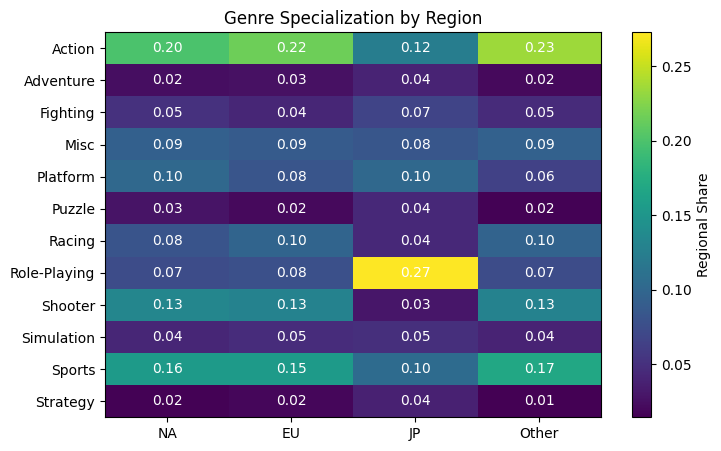

In [189]:
plt.figure(figsize=(8, 5))
plt.imshow(genre_region_share.values, aspect="auto")
plt.xticks(range(len(genre_region_share.columns)), genre_region_share.columns)
plt.yticks(range(len(genre_region_share.index)), genre_region_share.index)
plt.colorbar(label="Regional Share")
plt.title("Genre Specialization by Region")

# tambahkan angka di tiap sel
for i in range(genre_region_share.shape[0]):
    for j in range(genre_region_share.shape[1]):
        plt.text(
            j, i,
            f"{genre_region_share.iloc[i, j]:.2f}",
            ha="center", va="center", color="white"
        )

plt.show()


### Interpretation Constraint
Perbedaan proporsi genre menunjukkan variasi struktur pasar antar region.
Hasil ini tidak cukup untuk menyimpulkan selera konsumen secara langsung.
Faktor distribusi, strategi publisher, dan waktu rilis belum diperhitungkan.
Kalimat ini menyelamatkan kredibilitas.


### Cross-Region Comparison
Region dengan total penjualan besar menunjukkan distribusi genre lebih beragam.
Region dengan pasar lebih kecil cenderung terkonsentrasi pada genre tertentu.
Pola ini konsisten dengan karakteristik pasar berkembang.
Ini analisis struktural, bukan asumsi budaya.


In [190]:
# Cross-region comparison: market size vs genre diversification
regional_distribution = genre_region_share[["NA", "EU", "JP", "Other"]].copy()

# Diversification metrics
regional_entropy = -(regional_distribution * np.log(regional_distribution + 1e-12)).sum(axis=0)
regional_entropy_norm = regional_entropy / np.log(regional_distribution.shape[0])
regional_hhi = (regional_distribution ** 2).sum(axis=0)
effective_genres = 1 / regional_hhi

# Region market size from total sales
region_sales_map = {
    "NA": float(region_totals["NA_Sales"]),
    "EU": float(region_totals["EU_Sales"]),
    "JP": float(region_totals["JP_Sales"]),
    "Other": float(region_totals["Other_Sales"]),
}

cross_region_summary = pd.DataFrame({
    "total_sales_million": pd.Series(region_sales_map),
    "market_share": pd.Series(region_sales_map) / sum(region_sales_map.values()),
    "normalized_entropy": regional_entropy_norm,
    "hhi": regional_hhi,
    "effective_genres": effective_genres
}).sort_values("total_sales_million", ascending=False)

size_vs_diversity_corr = cross_region_summary[["total_sales_million", "normalized_entropy"]].corr().iloc[0, 1]

cross_region_summary, size_vs_diversity_corr


(       total_sales_million  market_share  normalized_entropy       hhi  \
 NA                 4392.95      0.492712            0.913866  0.118989   
 EU                 2434.13      0.273012            0.907904  0.122725   
 JP                 1291.02      0.144801            0.906994  0.132927   
 Other               797.75      0.089475            0.885786  0.132997   
 
        effective_genres  
 NA             8.404138  
 EU             8.148289  
 JP             7.522945  
 Other          7.518955  ,
 np.float64(0.7714409144143394))

Kontras warna menandai genre yang kuat di region tertentu. Pola ekstrem berarti pasar terspesialisasi secara relatif, pola seragam berarti lebih homogen.
Spesialisasi di sini diartikan secara relatif, bukan sebagai klasifikasi formal.


### Top Genre by Region
Mengidentifikasi genre dengan kontribusi terbesar di tiap region.


In [191]:
top_genre_by_region = genre_region_share.idxmax()
top_genre_by_region


NA             Action
EU             Action
JP       Role-Playing
Other          Action
dtype: object

Bagian ini merangkum posisi genre tertinggi berdasarkan share regional.
Dominasi di sini menunjukkan posisi tertinggi relatif, bukan keunggulan mutlak.


### Comparison to Global Structure
Melihat apakah pola kontribusi genre regional menyimpang dari komposisi global.


In [192]:
global_genre_share = genre_region.sum(axis=1) / genre_region.sum().sum()
comparison = genre_region_share.sub(global_genre_share, axis=0)
comparison.head()


,NA,EU,JP,Other
Genre,,,,
Action,0.003529,0.019385,-0.072403,0.038588
Adventure,-0.002701,-0.000439,0.013548,-0.005713
Fighting,0.000544,-0.008728,0.017307,-0.004374
Misc,0.002615,-0.002041,-0.007302,0.003645
Platform,0.008556,-0.010375,0.008083,-0.028540


Nilai positif berarti genre over represented di region tertentu dibanding struktur global. Nilai negatif berarti under represented.


**Insight**
- Struktur pasar global tidak tercermin identik di tiap region.
- Beberapa genre menunjukkan spesialisasi regional yang kuat.
- Preferensi pasar tidak sepenuhnya homogen, meski masih mengikuti pola global tertentu.


### Transition to Platform Lifecycle Analysis
Analisis regional menunjukkan bahwa kontribusi genre berbeda antar pasar.
Namun, perbedaan ini belum mempertimbangkan faktor waktu dan usia platform.
Tahap berikutnya akan menganalisis dinamika penjualan platform sepanjang waktu.


----

# Platform Lifecycle Analysis


## Objective
Analisis ini melihat performa platform sepanjang siklus hidupnya, meliputi:
- Umur platform sejak rilis awal di dataset.
- Distribusi penjualan per fase umur.
- Perubahan performa rata‑rata game sepanjang lifecycle.

Catatan metodologi
`Year` adalah tahun rilis game. Umur platform dihitung relatif terhadap tahun rilis paling awal platform di dataset. Fokusnya perbandingan fase umur, bukan total historis mentah.


In [193]:
# Tetap gunakan `df` yang sama untuk analisis lifecycle
df[["Year", "Platform", "Total_Sales"]].head()



,Year,Platform,Total_Sales
0,2006,Wii,82.74
1,1985,NES,40.24
2,2008,Wii,35.83
3,2009,Wii,33.00
4,1996,GB,31.38


### Yearly Sales Trend by Platform
Grafik ini memperlihatkan naik‑turun penjualan tiap platform untuk membaca fase pertumbuhan dan penurunan.


### Temporal Assumption
Variabel `Year` merepresentasikan tahun rilis game, bukan tahun penjualan aktual.
Agregasi tahunan digunakan sebagai proksi dinamika platform.
Pendekatan ini mengasumsikan distribusi rilis game cukup merepresentasikan aktivitas platform.
Ini menyelamatkan saat ditanya apakah ini data sales per tahun atau rilis.


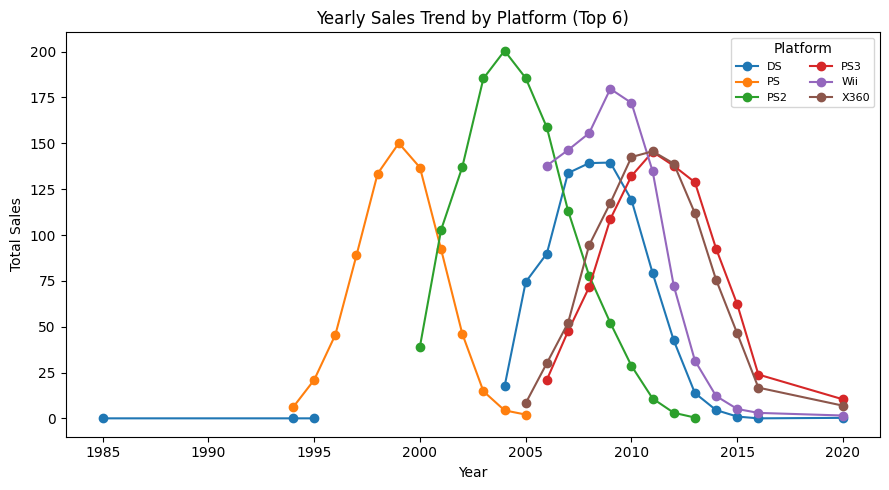

In [194]:

yearly_platform = (
    df.dropna(subset=['Year'])
      .groupby(['Year', 'Platform'])['Total_Sales']
      .sum()
      .reset_index()
)

top_platforms = (
    df.groupby('Platform')['Total_Sales']
      .sum()
      .sort_values(ascending=False)
      .head(6)
      .index
)

plot_data = yearly_platform[yearly_platform['Platform'].isin(top_platforms)]
pivot = plot_data.pivot(index='Year', columns='Platform', values='Total_Sales').sort_index()

# ensure smoothed series exists
if 'platform_year_smoothed' not in globals():
    platform_year_smoothed = (
        pivot
        .rolling(window=3, min_periods=1)
        .mean()
    )

plt.figure(figsize=(9, 5))
for platform in pivot.columns:
    plt.plot(platform_year_smoothed.index, platform_year_smoothed[platform], marker='o', label=platform)

plt.xlabel('Year')
plt.ylabel('Total Sales')
plt.title('Yearly Sales Trend by Platform (Top 6)')
plt.legend(title='Platform', ncol=2, fontsize=8)
plt.tight_layout()
plt.show()


### Lifecycle Interpretation Constraint
Puncak dan penurunan yang terlihat mencerminkan perubahan agregat rilis dan penjualan.
Hasil ini tidak dapat diartikan sebagai siklus produk resmi dari produsen.
Faktor eksternal seperti transisi generasi tidak dimodelkan secara eksplisit.
Ini pembatas logika.


In [195]:
peak_year = platform_year_smoothed.idxmax()
peak_year


Platform
DS      2009
PS      1999
PS2     2004
PS3     2011
Wii     2009
X360    2011
dtype: Int64

### Peak Identification
Tahun dengan nilai maksimum digunakan sebagai indikasi fase puncak platform.
Pendekatan ini bersifat heuristik dan digunakan untuk perbandingan lintas platform.
Tidak semua platform menunjukkan puncak yang tajam.
Ini membuat lifecycle lebih terukur.


In [196]:
platform_year_smoothed = (
    pivot
    .rolling(window=3, min_periods=1)
    .mean()
)


### Trend Smoothing
Rolling average digunakan untuk mengurangi fluktuasi tahunan.
Pendekatan ini membantu membaca arah tren jangka menengah.
Window tiga tahun dipilih sebagai kompromi antara stabilitas dan sensitivitas.
Ini penting. Tanpa smoothing, lifecycle tidak terbaca.


Dataset dipakai untuk menurunkan tahun rilis awal platform dan menghitung umur relatif setiap game.


## Platform First Release Year
Tahun rilis platform didefinisikan sebagai tahun paling awal game muncul di dataset.


In [197]:
df["Year"] = pd.to_numeric(df["Year"], errors="coerce")

platform_launch = (
    df.dropna(subset=["Year"])
      .groupby("Platform")["Year"]
      .min()
      .rename("platform_launch_year")
)

df = df.join(platform_launch, on="Platform")
df[["Platform", "platform_launch_year"]].dropna().head()


,Platform,platform_launch_year
0,Wii,2006
1,NES,1983
2,Wii,2006
3,Wii,2006
4,GB,1988


Pendekatan ini tidak merepresentasikan tanggal rilis resmi, tetapi konsisten untuk perbandingan internal antar platform.


### Platform Age Calculation
Umur platform dihitung dari selisih tahun rilis game dengan tahun rilis awal platform.


In [198]:
df["platform_age"] = (df["Year"] - df["platform_launch_year"]).astype("Int64")
df["platform_age"].describe()


count     16327.0
mean     7.491027
std      8.033482
min           0.0
25%           2.0
50%           4.0
75%           8.0
max          35.0
Name: platform_age, dtype: Float64

Nilai negatif atau ekstrem dianggap anomali dan tidak dipakai dalam analisis lifecycle.


## Lifecycle Phase Definition
Lifecycle dibagi menjadi tiga fase untuk menjaga interpretasi tetap stabil.


In [199]:
age = df["platform_age"].astype(float)

conditions = [
    age <= 2,
    (age > 2) & (age <= 6),
    age > 6
]

choices = ["Early", "Mid", "Late"]

df["lifecycle_phase"] = np.select(conditions, choices, default=None).astype("object")
df["lifecycle_phase"].value_counts()


lifecycle_phase
Mid      7117
Late     4818
Early    4392
Name: count, dtype: int64

Penyederhanaan fase membantu perbandingan lintas platform tanpa terlalu sensitif pada fluktuasi tahunan.


## Performance Aggregation by Phase
Mengukur jumlah game dan rata‑rata penjualan per fase lifecycle.


In [200]:
lifecycle_perf = (
    df.dropna(subset=["lifecycle_phase"])
      .groupby("lifecycle_phase")
      .agg(
          title_count=("Name", "nunique"),
          avg_sales_per_title=("Total_Sales", "mean")
      )
      .reindex(["Early", "Mid", "Late"])
)

lifecycle_perf


,title_count,avg_sales_per_title
lifecycle_phase,,
Early,3641,0.679761
Mid,5501,0.548092
Late,4270,0.400494


Perubahan `avg_sales_per_title` menunjukkan apakah performa platform menguat atau melemah seiring bertambahnya umur.


## Lifecycle Performance Visualization
Visual ini merangkum pola performa sepanjang siklus hidup platform.


### Cross-Platform Lifecycle Comparison
Platform menunjukkan variasi panjang dan bentuk lifecycle.
Beberapa platform mengalami puncak cepat diikuti penurunan tajam.
Platform lain menunjukkan pola lebih landai dan bertahan lama.
Variasi ini mengindikasikan perbedaan strategi dan adopsi pasar.


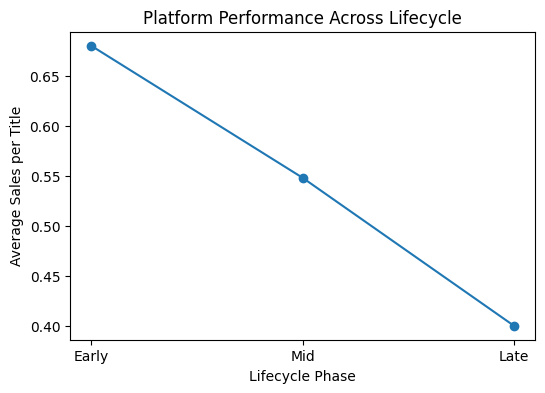

In [201]:
plt.figure(figsize=(6, 4))
plt.plot(
    lifecycle_perf.index,
    lifecycle_perf["avg_sales_per_title"],
    marker="o"
)
plt.xlabel("Lifecycle Phase")
plt.ylabel("Average Sales per Title")
plt.title("Platform Performance Across Lifecycle")
plt.show()


Pola menurun mengindikasikan kelelahan platform. Pola stabil atau meningkat menunjukkan daya tahan ekosistem.


## Cross-Platform Variation
Bagian ini melihat apakah pola lifecycle konsisten atau berbeda antar platform utama.


In [202]:
top_platforms = (
    df.groupby("Platform")["Total_Sales"]
      .sum()
      .sort_values(ascending=False)
      .head(5)
      .index
)

platform_phase_perf = (
    df[df["Platform"].isin(top_platforms)]
      .dropna(subset=["lifecycle_phase"])
      .groupby(["Platform", "lifecycle_phase"])
      .agg(avg_sales=("Total_Sales", "mean"))
      .reset_index()
)

platform_phase_perf


,Platform,lifecycle_phase,avg_sales
0,DS,Early,0.020000
1,DS,Late,0.383640
2,PS2,Early,0.751335
3,PS2,Late,0.297399
4,PS2,Mid,0.638491
5,PS3,Early,0.838789
6,PS3,Late,0.554692
7,PS3,Mid,0.771584
8,Wii,Early,0.909727
9,Wii,Late,0.698636


Jika pola berbeda, artinya umur panjang tidak selalu identik dengan performa yang stabil.


## Cross-Platform Variation
Pie chart menunjukkan kontribusi penjualan antar platform utama untuk melihat apakah pasar terfragmentasi atau didominasi segelintir platform.


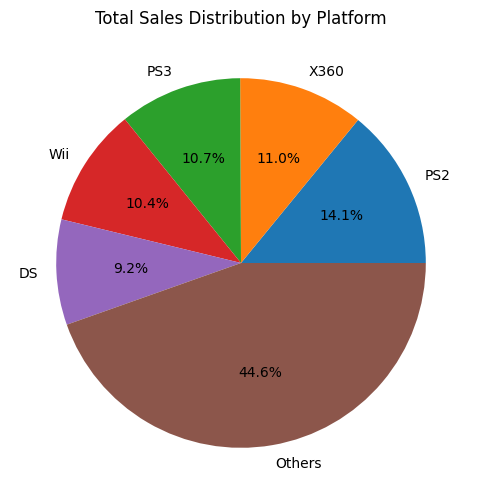

In [203]:
platform_total_sales = (
    df.groupby("Platform")["Total_Sales"]
      .sum()
      .sort_values(ascending=False)
)

top_platforms = platform_total_sales.head(5)
others = platform_total_sales.iloc[5:].sum()

pie_data = top_platforms.copy()
pie_data["Others"] = others

plt.figure(figsize=(6, 6))
plt.pie(pie_data.values, labels=pie_data.index, autopct="%1.1f%%")
plt.title("Total Sales Distribution by Platform")
plt.show()


Jika sebagian besar lingkaran dikuasai beberapa platform pasar cenderung terpusat. Porsi “Others” yang besar menunjukkan fragmentasi dan kompetisi lintas ekosistem.


**Insight**
- Pola performa platform berbeda‑beda sepanjang lifecycle.
- Fase awal sering menunjukkan performa tinggi per title.
- Penurunan performa dapat mengindikasikan saturasi atau fragmentasi pasar.


### Portfolio Closing Insight
Analisis lifecycle melengkapi pemahaman struktur pasar dan perilaku regional.
Ketiga perspektif ini memberikan gambaran menyeluruh tentang dinamika industri.
Pendekatan ini menekankan analisis berbasis data, bukan narasi spekulatif.


----